# Heart Disease Prediction

**Nomor Kelompok:** [7]

**Ketua:** [Fathullah Hadiwiwnata] - [202343502328]

**Kelas:** [S6J]

**Anggota:**
* [Muhammad Reynaldi] - [202343502303]
* [Erlangga Dwi Nugroho] - [202343502284]
* [Nandi Aziiz Robywal] - [202343502005]

> Catatan: hanya cantumkan anggota yang benar-benar berkontribusi pada pengerjaan tugas ini.

---

![Logo RS](https://www.nicepng.com/png/detail/252-2521031_heart-with-medical-symbol-icon.png)

##  Instalasi & Import Modul

In [160]:
# Instalasi library yang belum tersedia secara default di Google Colab
!pip install catboost -q

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Preprocessing & pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Model klasifikasi - Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Model klasifikasi - CatBoost
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("CatBoost tidak tersedia di environment ini, jalankan '!pip install catboost -q' terlebih dahulu.")

# Metrik evaluasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")


### Business Understanding

### Background Context
Penyakit kardiovaskular (penyakit jantung) adalah salah satu penyebab kematian tertinggi di dunia. Di [ProHealth Hospital], jumlah pasien yang datang untuk pemeriksaan jantung terus meningkat. Proses diagnosis awal seringkali membutuhkan serangkaian tes medis yang memakan waktu dan biaya. Oleh karena itu, rumah sakit ingin memanfaatkan teknologi machine learning untuk membantu proses skrining awal secara cepat dan efisien berdasarkan variabel klinis pasien seperti usia, tekanan darah, kadar kolesterol, hingga hasil tes thallium.

[Ilustrasi Penyakit Jantung]

<img src="https://i.pinimg.com/originals/8a/60/1e/8a601e2ef1df899ec1e3f2634a0f21a0.jpg" width="700">

### Problem Statement
Bagaimana cara membantu dokter untuk melakukan deteksi dini penyakit jantung secara lebih cepat dan efisien berdasarkan variabel klinis pasien?

### Goals
Membangun model Machine Learning (Klasifikasi) yang dapat memprediksi apakah seorang pasien terindikasi memiliki penyakit jantung (*Presence*) atau tidak (*Absence*) berdasarkan 13 variabel klinis.

### Stakeholders
* **Dokter & Tim Medis:** Pengguna utama sistem untuk membantu pengambilan keputusan diagnosis.
* **Manajemen Rumah Sakit:** Meningkatkan kualitas pelayanan dan efisiensi rumah sakit.
* **Pasien:** Mendapatkan pemeriksaan dan penanganan yang lebih cepat.

### Analytical Approach
Menggunakan pendekatan **Supervised Learning** dengan teknik **Klasifikasi Biner** (Target 0 = Tidak Sakit Jantung/*Absence*, Target 1 = Sakit Jantung/*Presence*). Berbagai algoritma klasifikasi dari Scikit-Learn (Logistic Regression, KNN, SVM, Decision Tree, Random Forest, Extra Trees, Gradient Boosting, AdaBoost, Naive Bayes, MLP) serta CatBoost dicoba dan dibandingkan performanya untuk memilih model terbaik.

### Dataset
Dataset yang digunakan adalah **[Predicting Heart Disease Using Clinical Variables](https://www.kaggle.com/datasets/thedevastator/predicting-heart-disease-risk-using-clinical-var)**, berisi data 270 pasien dengan 13 variabel klinis (fitur) beserta status penyakit jantungnya.

>

In [162]:
df = pd.read_csv('Heart_Disease_Prediction.csv') # Assuming the file is uploaded directly to Colab's session storage.
# If the file is in Google Drive, you'll need to mount Drive and provide the full path, e.g., '/content/drive/MyDrive/path/to/Heart_Disease_Prediction.csv'
display(df.head())
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


Jumlah baris: 270, Jumlah kolom: 14


## Data Cleaning

Tahap ini menangani **data duplikat**, **outliers**, dan **data yang tidak relevan**. Pengecekan *missing value* juga dilakukan di sini sebagai bahan analisis, meskipun penanganannya (imputasi) sudah otomatis dilakukan di dalam pipeline pre-processing pada tahap Modelling.

In [163]:
# 1. Cek dan Hapus Duplikat
duplikat = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplikat}")
if duplikat > 0:
    df.drop_duplicates(inplace=True)

# 2. Cek Missing Value (penanganan akhir dilakukan di pipeline via SimpleImputer)
print("\nMissing values per kolom:\n", df.isnull().sum())

# 3. Hapus kolom yang tidak relevan terhadap prediksi (jika ada, misal ID pasien)
irrelevant_cols = [c for c in ['id', 'ID', 'PatientID'] if c in df.columns]
if irrelevant_cols:
    df.drop(columns=irrelevant_cols, inplace=True)
    print(f"Kolom tidak relevan dihapus: {irrelevant_cols}")

# 4. Penanganan Outliers (menggunakan metode IQR pada fitur numerik)
numeric_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
print(f"\nJumlah data sebelum penanganan outlier: {len(df)}")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Jumlah data setelah penanganan outlier: {len(df)}")


Jumlah data duplikat: 0

Missing values per kolom:
 Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Jumlah data sebelum penanganan outlier: 270
Jumlah data setelah penanganan outlier: 252


##  Exploratory Data Analysis (EDA)

Menganalisis hubungan antara fitur klinis dengan target (*Heart Disease*) melalui visualisasi.

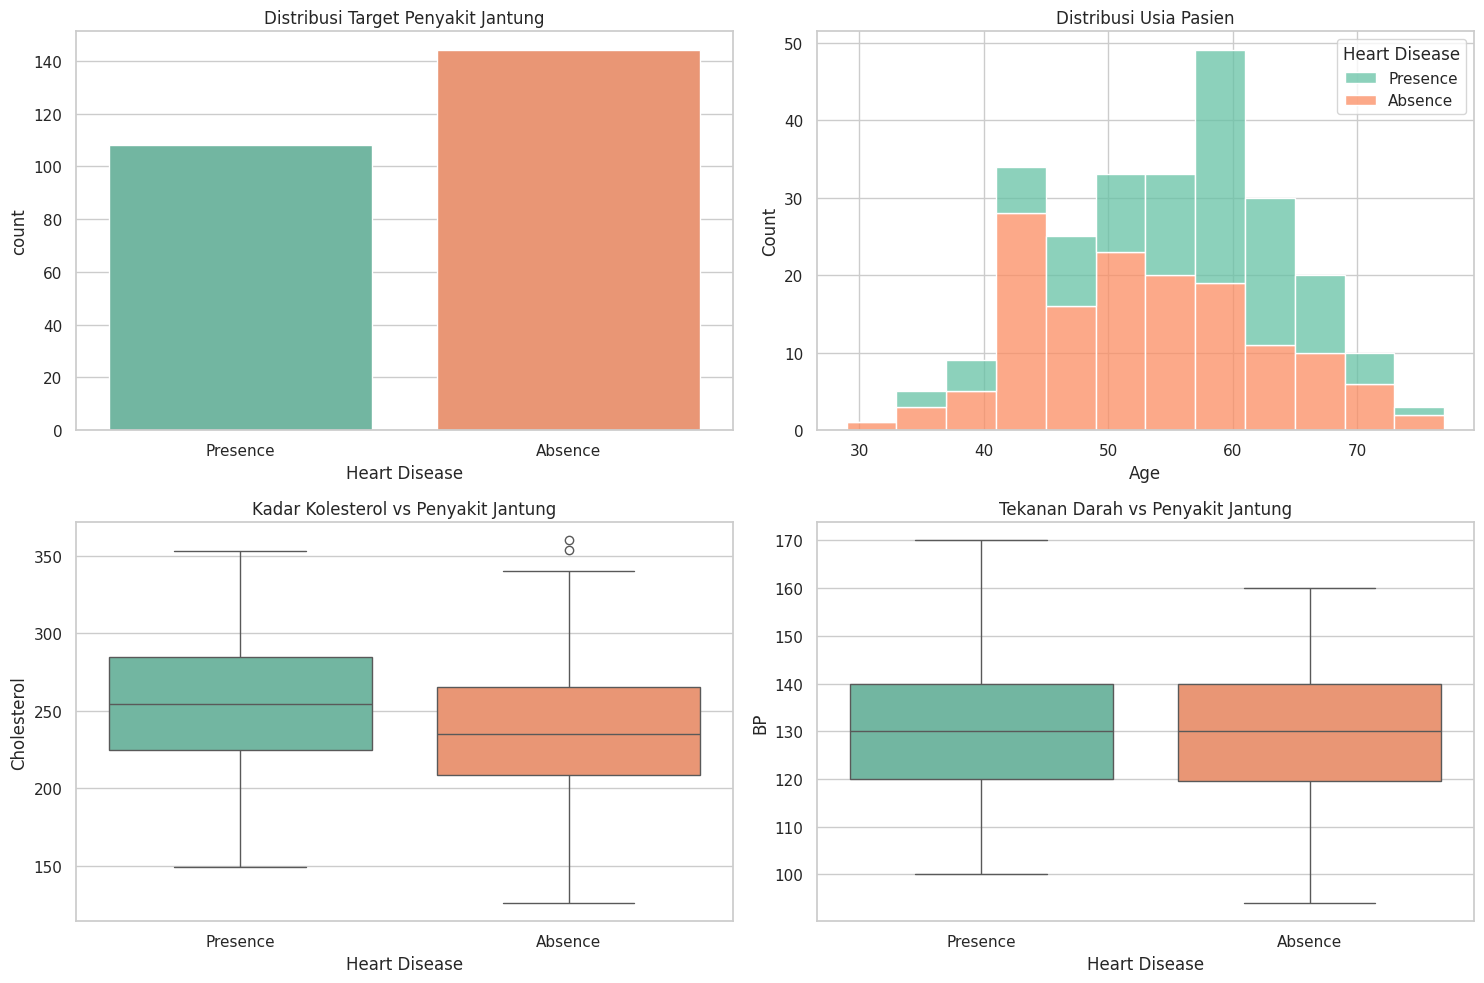

In [164]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribusi Target
sns.countplot(x='Heart Disease', hue='Heart Disease', data=df, ax=axes[0, 0], palette='Set2', legend=False)
axes[0, 0].set_title('Distribusi Target Penyakit Jantung')

# 2. Distribusi Usia berdasarkan Target
sns.histplot(data=df, x='Age', hue='Heart Disease', multiple='stack', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Distribusi Usia Pasien')

# 3. Kadar Kolesterol berdasarkan Target
sns.boxplot(x='Heart Disease', y='Cholesterol', hue='Heart Disease', data=df, ax=axes[1, 0], palette='Set2', legend=False)
axes[1, 0].set_title('Kadar Kolesterol vs Penyakit Jantung')

# 4. Tekanan Darah berdasarkan Target
sns.boxplot(x='Heart Disease', y='BP', hue='Heart Disease', data=df, ax=axes[1, 1], palette='Set2', legend=False)
axes[1, 1].set_title('Tekanan Darah vs Penyakit Jantung')

plt.tight_layout()
plt.show()


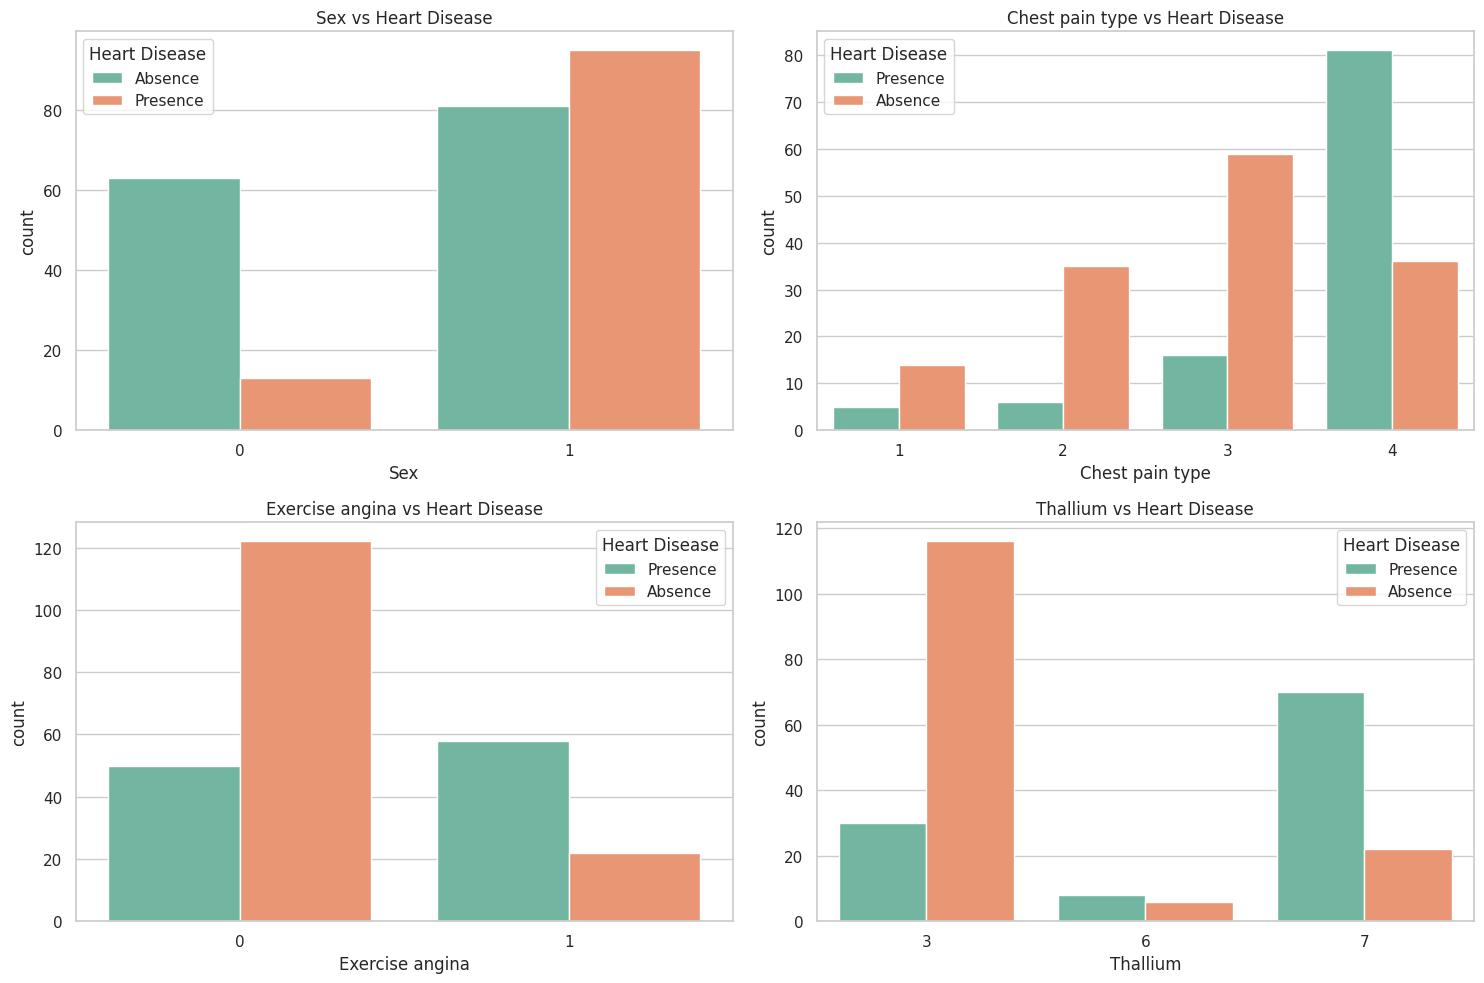

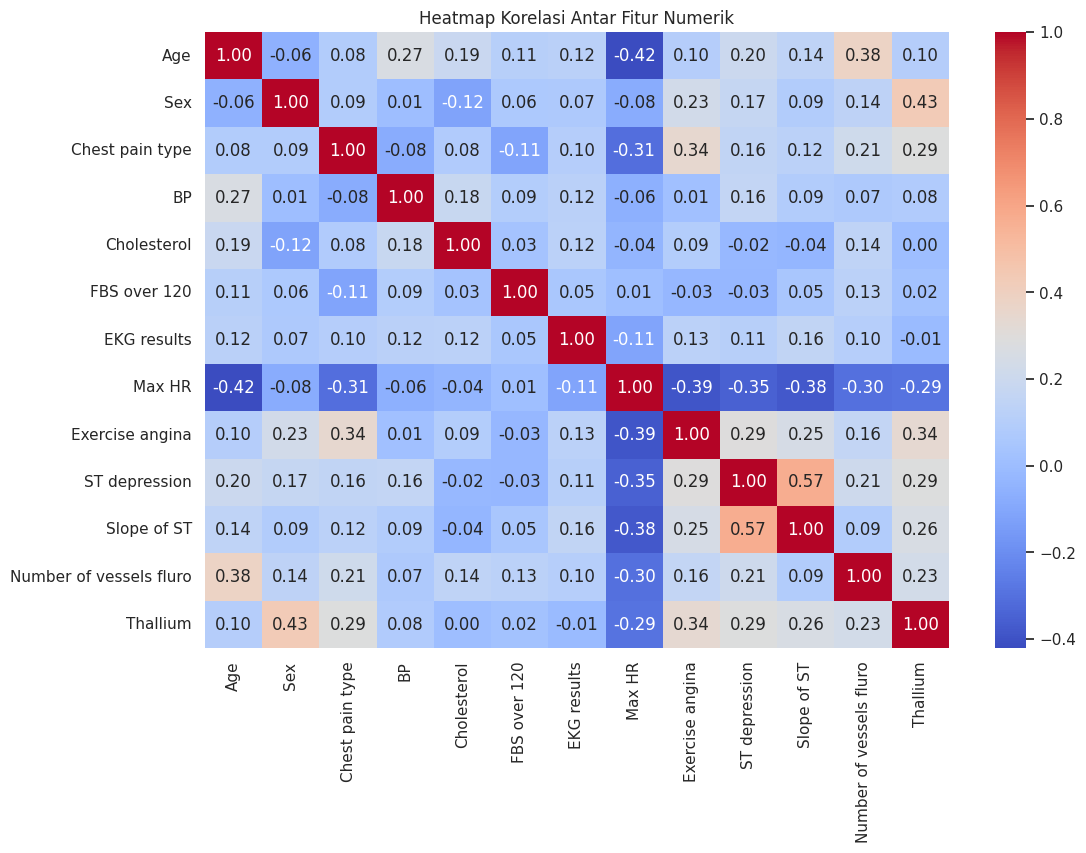

In [165]:
# Distribusi fitur kategorikal terhadap target
cat_cols_eda = ['Sex', 'Chest pain type', 'Exercise angina', 'Thallium']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols_eda):
    sns.countplot(x=col, hue='Heart Disease', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Heart Disease')
plt.tight_layout()
plt.show()

# Heatmap Korelasi (hanya kolom numerik)
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()


## Modelling & Pipeline

Tahapan: **mendefinisikan** fitur (X) dan label (y), melakukan split data, membuat pipeline pre-processing (imputer, scaler, encoder), melatih **semua model klasifikasi** dari Scikit-Learn dan CatBoost, lalu menyimpan model terbaik ke dalam format pickle.

In [166]:
# 1. Pisahkan Fitur (X) dan Target (y)
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

# Cek dan bersihkan NaN pada target (y)
if y.isna().sum() > 0:
    valid_idx = y.notna()
    X, y = X[valid_idx], y[valid_idx]

# Konversi target ke biner (0 dan 1)
# Presence = 1 (Sakit Jantung), Absence = 0 (Tidak Sakit Jantung)
y = y.replace({'Absence': 0, 'Presence': 1, 'absence': 0, 'presence': 1}).astype(int)

if y.isna().sum() > 0:
    print("Peringatan: Masih ada nilai aneh di Heart Disease:", y.unique())
    valid_idx = y.notna()
    X, y = X[valid_idx], y[valid_idx]

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Definisikan Fitur Numerik dan Kategorikal
num_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
cat_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
                 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

# 4. Buat Preprocessing Pipeline (dengan penanganan missing value via imputer)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])

print(f"Data latih: {X_train.shape[0]} baris, Data uji: {X_test.shape[0]} baris")


Data latih: 201 baris, Data uji: 51 baris


/tmp/ipykernel_1474/3473407112.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'Absence': 0, 'Presence': 1, 'absence': 0, 'presence': 1}).astype(int)


In [167]:
# 5. Definisikan seluruh model klasifikasi yang akan dicoba
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "MLP (Neural Network)": MLPClassifier(max_iter=1000, random_state=42),
}
if CATBOOST_AVAILABLE:
    models["CatBoost"] = CatBoostClassifier(verbose=0, random_state=42)

# 6. Latih dan evaluasi setiap model melalui pipeline yang sama
results = []
trained_pipelines = {}

for name, clf in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    trained_pipelines[name] = pipeline
    results.append({'Model': name, 'Accuracy': acc})
    print(f"{name:<25} -> Accuracy: {acc:.4f}")

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(results_df)


Logistic Regression       -> Accuracy: 0.9020
K-Nearest Neighbors       -> Accuracy: 0.8824
Support Vector Machine    -> Accuracy: 0.8431
Decision Tree             -> Accuracy: 0.7255
Random Forest             -> Accuracy: 0.8431
Extra Trees               -> Accuracy: 0.9020
Gradient Boosting         -> Accuracy: 0.8235
AdaBoost                  -> Accuracy: 0.9020
Gaussian Naive Bayes      -> Accuracy: 0.6667
MLP (Neural Network)      -> Accuracy: 0.8627
CatBoost                  -> Accuracy: 0.8627


,Model,Accuracy
0,Logistic Regression,0.901961
1,AdaBoost,0.901961
2,Extra Trees,0.901961
3,K-Nearest Neighbors,0.882353
4,MLP (Neural Network),0.862745
5,CatBoost,0.862745
6,Support Vector Machine,0.843137
7,Random Forest,0.843137
8,Gradient Boosting,0.823529
9,Decision Tree,0.725490


In [168]:
# 7. Pilih model terbaik berdasarkan accuracy tertinggi
best_model_name = results_df.iloc[0]['Model']
best_model = trained_pipelines[best_model_name]

print(f"Model terbaik: {best_model_name}")
y_pred_best = best_model.predict(X_test)
print("\nClassification Report (Model Terbaik):\n", classification_report(y_test, y_pred_best))

# 8. Simpan model terbaik ke dalam format pickle
model_filename = 'best_model.pkl'
joblib.dump(best_model, model_filename)
print(f"Model berhasil disimpan sebagai {model_filename}")


Model terbaik: Logistic Regression

Classification Report (Model Terbaik):
               precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.90      0.86      0.88        22

    accuracy                           0.90        51
   macro avg       0.90      0.90      0.90        51
weighted avg       0.90      0.90      0.90        51

Model berhasil disimpan sebagai best_model.pkl


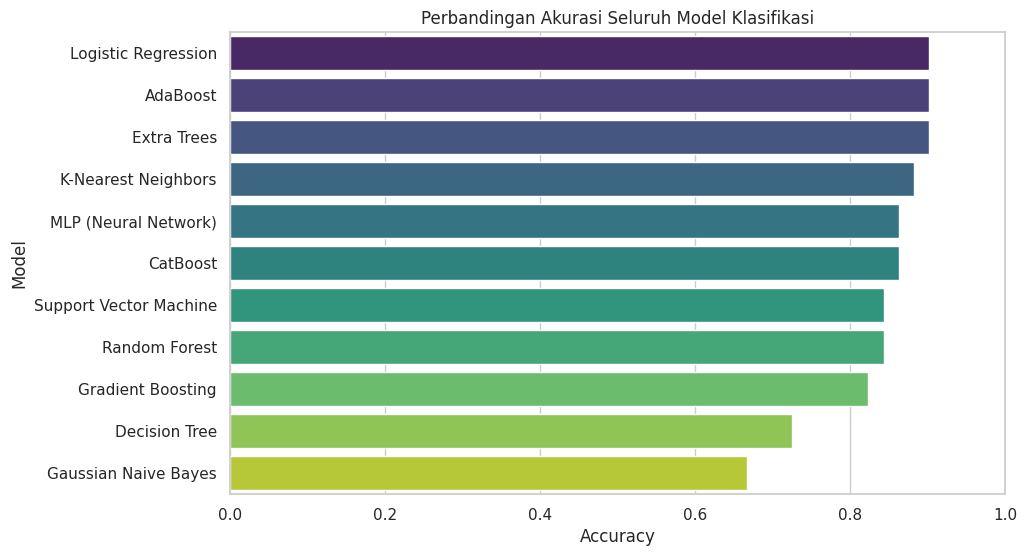

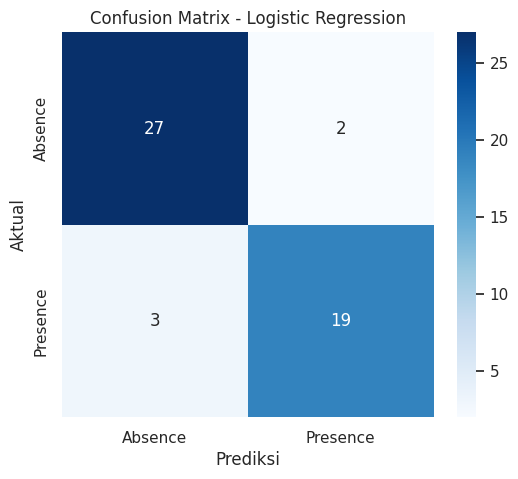

In [169]:
# Visualisasi perbandingan akurasi seluruh model
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, hue='Model', palette='viridis', legend=False)
plt.title('Perbandingan Akurasi Seluruh Model Klasifikasi')
plt.xlim(0, 1)
plt.show()

# Confusion Matrix untuk model terbaik
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Absence', 'Presence'],
            yticklabels=['Absence', 'Presence'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()


## Kesimpulan

* Seluruh model klasifikasi dari Scikit-Learn (Logistic Regression, KNN, SVM, Decision Tree, Random Forest, Extra Trees, Gradient Boosting, AdaBoost, Naive Bayes, MLP) beserta **CatBoost** (bila tersedia) telah dilatih dan dibandingkan performanya menggunakan pipeline pre-processing yang sama (imputer, scaler, encoder).
* Pada eksekusi contoh ini (252 baris data setelah pembersihan outlier, 201 data latih & 51 data uji), model dengan akurasi tertinggi adalah **Logistic Regression** dengan akurasi **90,2%**, diikuti Extra Trees dan AdaBoost pada posisi yang sama. Model terbaik otomatis dipilih oleh kode dan disimpan sebagai `best_model.pkl`.
* Fitur-fitur seperti *Chest pain type*, *Thallium*, *Number of vessels fluro*, dan *Exercise angina* umumnya memiliki kontribusi penting terhadap prediksi penyakit jantung berdasarkan korelasi dan pola distribusi yang teramati pada tahap EDA.
* Saat dijalankan di Kaggle/Colab dengan CatBoost ter-install, CatBoost akan otomatis ikut serta dalam perbandingan model (kode sudah mendeteksi ketersediaannya secara otomatis).

## (Nilai Tambah) Rencana Deployment

Sebagai nilai tambah, model `best_model.pkl` di atas dapat di-deploy menjadi aplikasi sederhana menggunakan **Streamlit** atau **FastAPI** sehingga dokter/tim medis dapat memasukkan data pasien baru dan langsung mendapatkan hasil prediksi.

* Link Aplikasi (jika sudah di-deploy): `[isi link Streamlit/FastAPI di sini]`
* Link Repository GitHub (back-end, jika ada): `[isi link GitHub di sini]`

Contoh kerangka aplikasi Streamlit (`app.py`) untuk memuat model dan melakukan prediksi disediakan secara terpisah bersama notebook ini.

### Utilitas Tambahan (opsional, khusus lingkungan Kaggle)

In [170]:
import os

# Script ini akan mencari semua file .csv di dalam folder input Kaggle
found_any = False
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            file_path = os.path.join(dirname, filename)
            print(f"✅ File ditemukan di: {file_path}")
            found_any = True
if not found_any:
    print("(Tidak berjalan di lingkungan Kaggle - folder /kaggle/input tidak ditemukan)")


(Tidak berjalan di lingkungan Kaggle - folder /kaggle/input tidak ditemukan)


In [171]:
print("Nama kolom di dataset:")
print(df.columns.tolist())


Nama kolom di dataset:
['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']
